In [4]:
import sys
sys.path.append('../')

In [5]:
from qpbl.QPBL import Eigen, Utils
import pennylane as qml
from matplotlib import pyplot as plt

In [6]:
IQubits = 1
PQubits = 2
LQubits = 5
QQubits = 2
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits

In [16]:
dev = qml.device("default.qubit", wires=10, shots=1000)
@qml.qnode(dev)
def OperatorSuperposition(parameters):
    for i in range(1):
        qml.Hadamard(wires=i)
    qml.RX(parameters[0], wires=1)
    qml.RX(parameters[1], wires=2)
    qml.ctrl(Eigen(theta=parameters,wire=range(3,10),IndexQubits=1, LQubits=5, QQubits=2, O="X"), control=(0), control_values=Utils.int_to_bin(n=0, num_bits=1))
    qml.ctrl(Eigen(theta=parameters,wire=range(3,10),IndexQubits=1, LQubits=5, QQubits=2, O="I"), control=(0), control_values=Utils.int_to_bin(n=1, num_bits=1))
    return [qml.probs(wires=range(3,8)),qml.probs(wires=range(8,10))]

(<Figure size 600x1100 with 1 Axes>, <Axes: >)


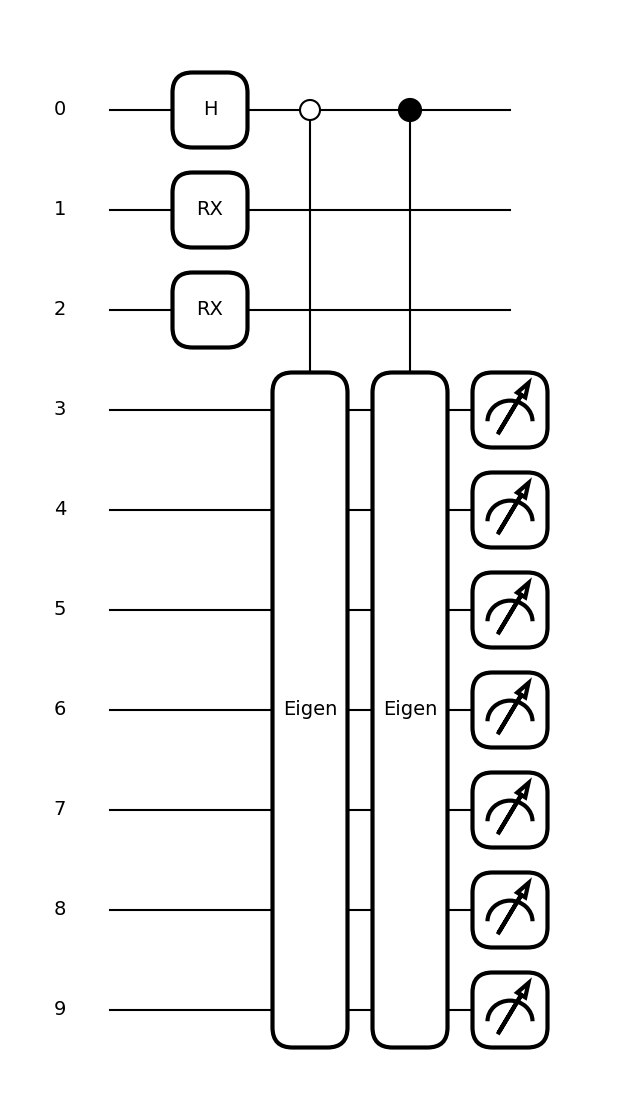

In [17]:
circuit = qml.QNode(OperatorSuperposition, dev)
print(qml.draw_mpl(circuit)([0,0]))

In [18]:
results = circuit([0,0])

array([0.766, 0.   , 0.   , 0.234])

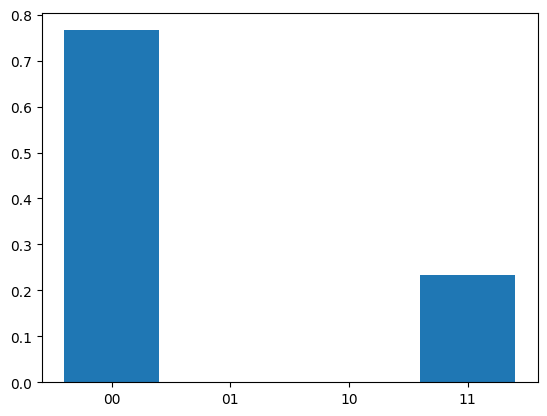

In [19]:
bit_strings = [f"{x:0{2}b}" for x in range(len(results[1]))]
plt.bar(bit_strings, results[1])
results[1]

array([0.761, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.239, 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   ])

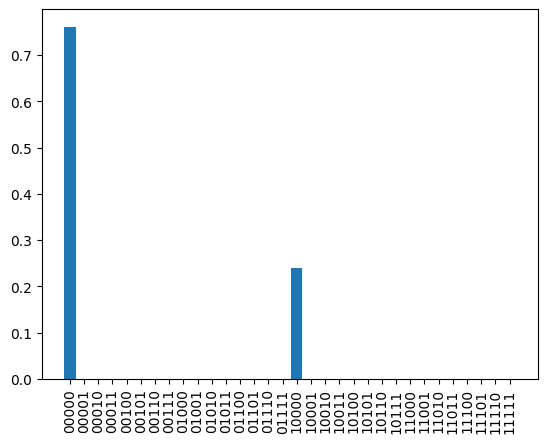

In [20]:
bit_strings = [f"{x:0{5}b}" for x in range(len(results[0]))]
plt.bar(bit_strings, results[0])
plt.xticks(rotation=90)
results[0]

In [25]:
dev2 = qml.device("default.qubit", wires=10, shots=1000)
@qml.qnode(dev2)
def OperatorSuperposition2(parameters):
    for i in range(1):
        qml.Hadamard(wires=i)
    qml.RX(parameters[0], wires=1)
    qml.RX(parameters[1], wires=2)
    qml.ctrl(Eigen(theta=parameters,wire=range(3,10),IndexQubits=1, LQubits=5, QQubits=2, O="X"), control=(0), control_values=Utils.int_to_bin(n=0, num_bits=1))
    qml.ctrl(Eigen(theta=parameters,wire=range(3,10),IndexQubits=1, LQubits=5, QQubits=2, O="X"), control=(0), control_values=Utils.int_to_bin(n=1, num_bits=1))
    return [qml.probs(wires=range(3,8)),qml.probs(wires=range(8,10))]

(<Figure size 600x1100 with 1 Axes>, <Axes: >)


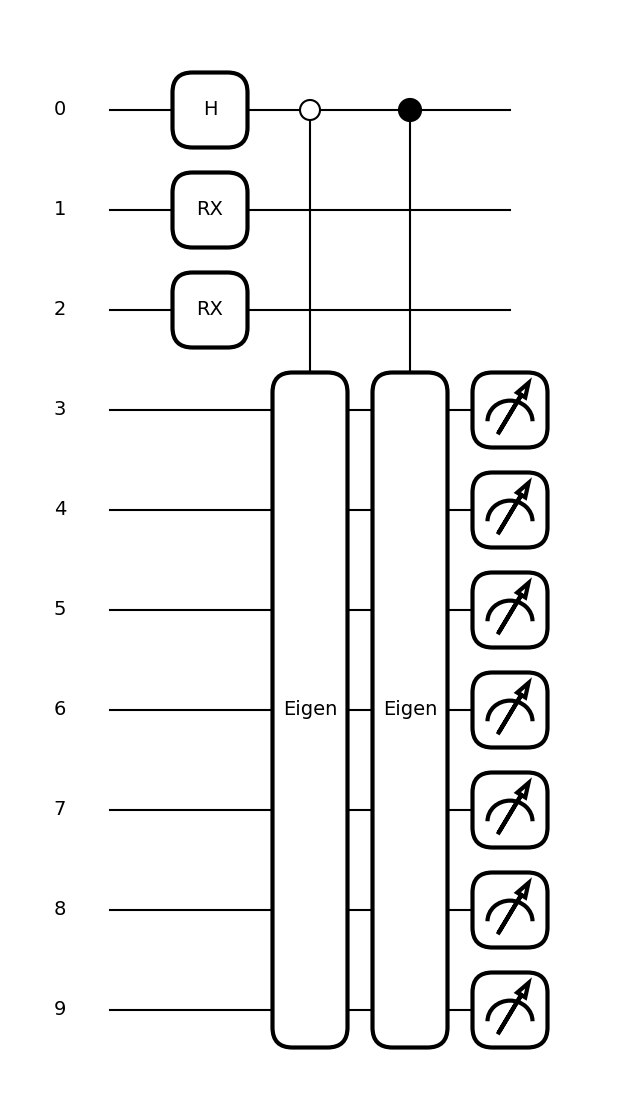

In [26]:
circuit2 = qml.QNode(OperatorSuperposition2, dev2)
print(qml.draw_mpl(circuit2)([0,0]))

In [27]:
results2 = circuit2([0,0])

array([0.513, 0.   , 0.   , 0.487])

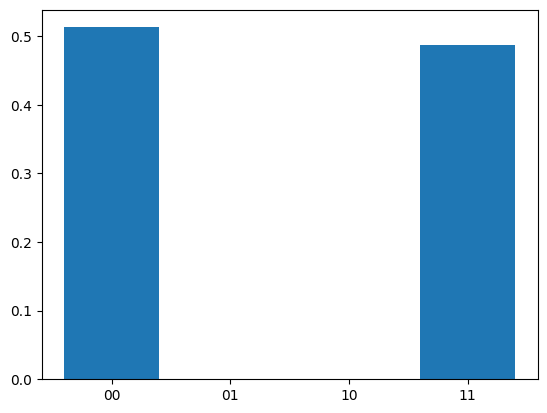

In [28]:
bit_strings = [f"{x:0{2}b}" for x in range(len(results2[1]))]
plt.bar(bit_strings, results2[1])
results2[1]

array([0.486, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.514, 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   ])

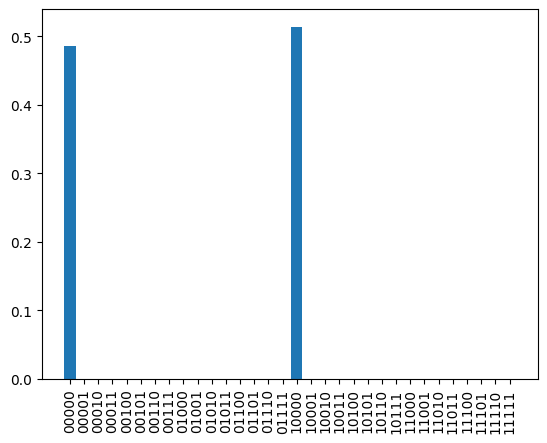

In [30]:
bit_strings = [f"{x:0{5}b}" for x in range(len(results2[0]))]
plt.bar(bit_strings, results2[0])
plt.xticks(rotation=90)
results2[0]